In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
ROOT_DIR = '/content/gdrive/My Drive/TrainYolov8CustomDataset/Construction Site Safety.v27-yolov8.yolov8'

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.7 MB/s eta 0:00:00


In [ ]:
import shutil

ROOT = '/content/gdrive/My Drive/TrainYolov8CustomDataset/Construction Site Safety.v27-yolov8.yolov8'

# Only fix valid
shutil.move(f'{ROOT}/valid/images/labels', f'{ROOT}/valid/labels')

print("Done! ✅")

In [ ]:
import shutil
shutil.copytree(
    '/content/drive/My Drive/TrainYolov8CustomDataset/Construction Site Safety.v27-yolov8.yolov8',
    '/content/dataset'
)

'/content/dataset'

In [ ]:
shutil.copytree(
    '/content/drive/My Drive/TrainYolov8CustomDataset/runs',
    '/content/runs'
)

'/content/runs'

In [ ]:
# first model
import os
from ultralytics import YOLO

model = YOLO("yolov8s.yaml")
# ✅ Correct - using local storage (fast!)
results = model.train(data='/content/dataset/data.yaml', epochs=50)

ModuleNotFoundError: No module named 'ultralytics'

In [ ]:
# Precision   is  63%

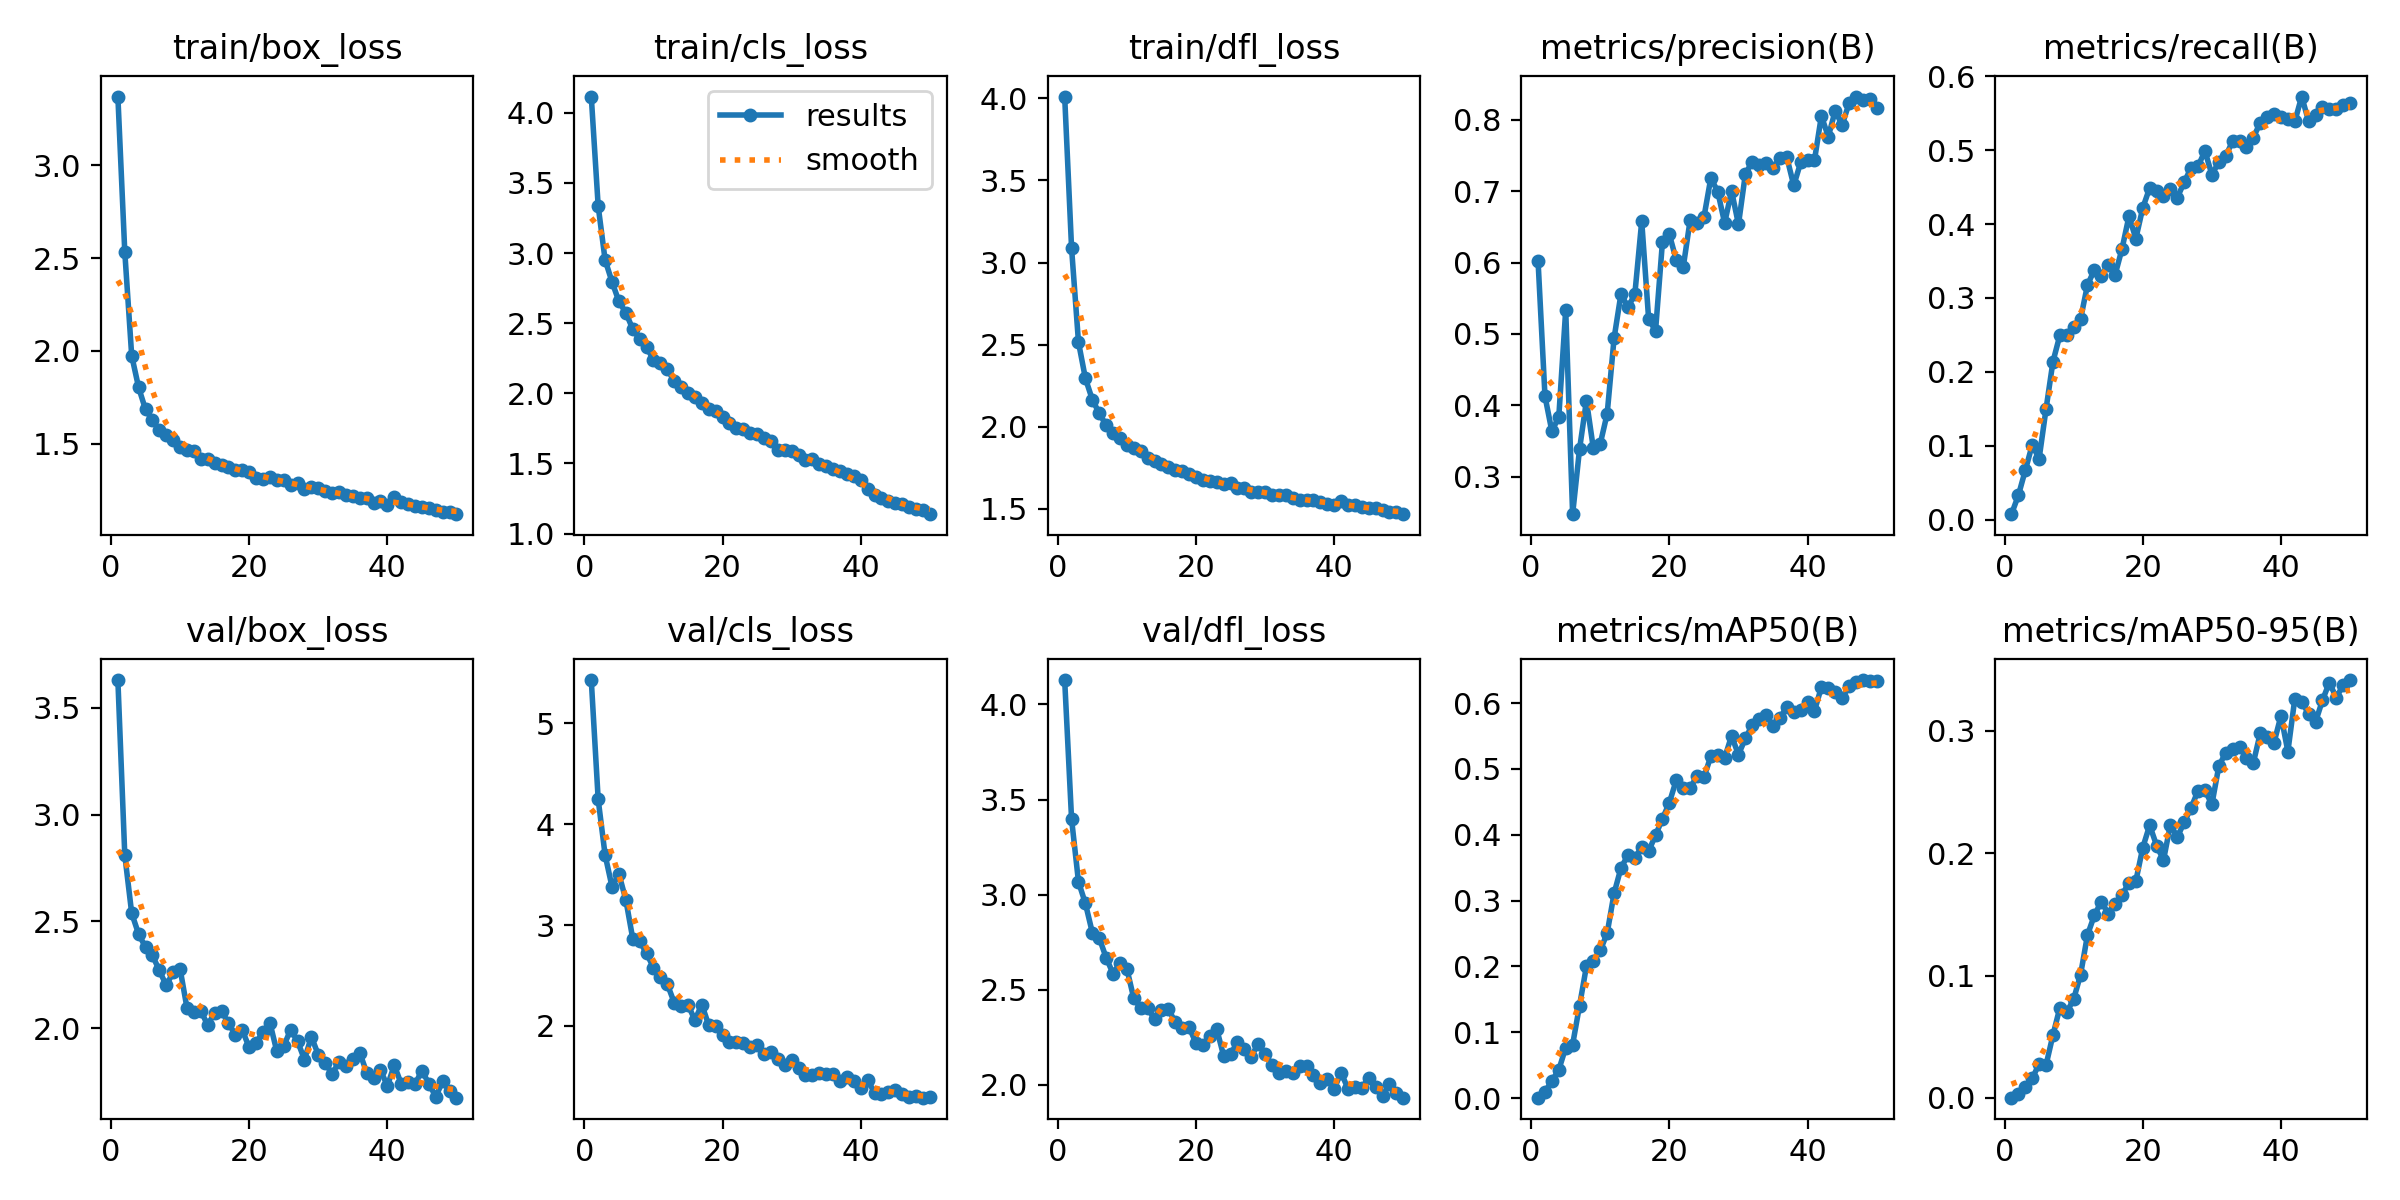

In [ ]:
from IPython.display import Image
Image('/content/runs/detect/train5/results.png')

In [ ]:
!scp -r /content/runs '/content/drive/My Drive/TrainYolov8CustomDataset'

In [ ]:
from ultralytics import YOLO

# Load your best trained model
model = YOLO('/content/runs/detect/train5/weights/best.pt')

# Run inference on test images
results = model.predict('/content/dataset/test/images', save=True)


image 1/82 /content/dataset/test/images/-4405-_png_jpg.rf.82b5c10b2acd1cfaa24259ada8e599fe.jpg: 640x640 2 machinerys, 16.2ms
image 2/82 /content/dataset/test/images/000005_jpg.rf.96e9379ccae638140c4a90fc4b700a2b.jpg: 640x640 2 Hardhats, 1 NO-Mask, 1 NO-Safety Vest, 1 Person, 1 machinery, 16.3ms
image 3/82 /content/dataset/test/images/002551_jpg.rf.ce4b9f934161faa72c80dc6898d37b2d.jpg: 640x640 2 Hardhats, 1 NO-Mask, 1 NO-Safety Vest, 2 Persons, 1 Safety Vest, 1 machinery, 16.1ms
image 4/82 /content/dataset/test/images/003357_jpg.rf.9867f91e88089bb68dc95947d5116d14.jpg: 640x640 1 NO-Safety Vest, 1 Person, 1 Safety Cone, 1 vehicle, 16.1ms
image 5/82 /content/dataset/test/images/004063_jpg.rf.1b7cdc4035bcb24ef69b8798b444053e.jpg: 640x640 2 Hardhats, 4 NO-Safety Vests, 5 Persons, 1 machinery, 16.1ms
image 6/82 /content/dataset/test/images/004763_jpg.rf.46484e6ca73caeaa9de45822cf1085a9.jpg: 640x640 3 Hardhats, 2 NO-Masks, 2 NO-Safety Vests, 2 Persons, 16.1ms
image 7/82 /content/dataset/test


image 1/1 /content/drive/MyDrive/TrainYolov8CustomDataset/runs/detect/predict/pic4.png: 448x640 2 NO-Safety Vests, 3 Persons, 259.3ms
Speed: 22.2ms preprocess, 259.3ms inference, 3.8ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/ppe_result


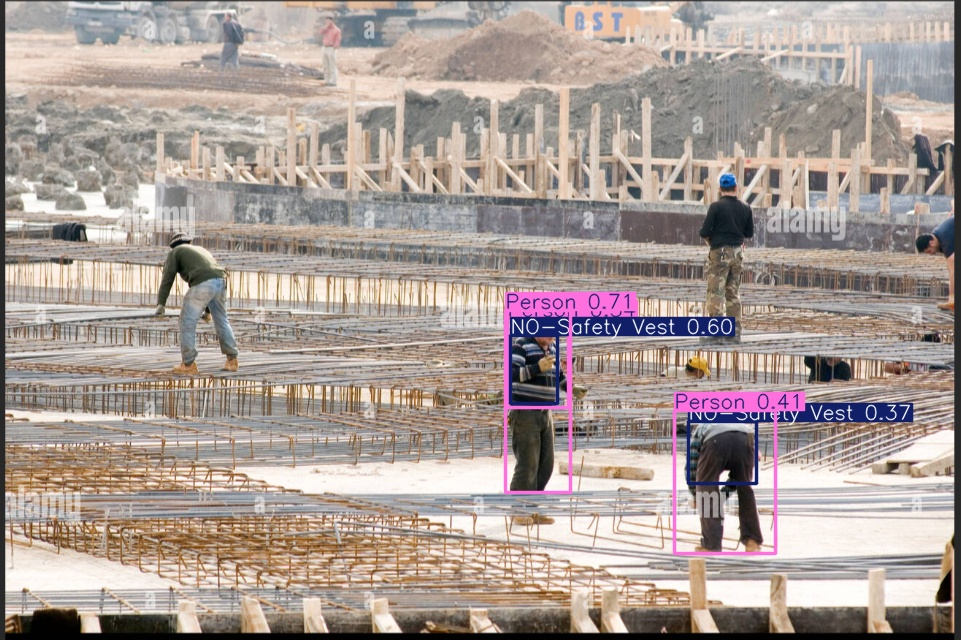

In [ ]:
from ultralytics import YOLO
from IPython.display import display, Image
import glob

model_ppe = YOLO('/content/drive/MyDrive/TrainYolov8CustomDataset/runs/detect/train5/weights/best.pt')

# ↓ CHANGE IMAGE PATH HERE
image_path = '/content/drive/MyDrive/TrainYolov8CustomDataset/runs/detect/predict/pic4.png'

model_ppe.predict(source=image_path, conf=0.3, save=True, name='ppe_result', exist_ok=True)
display(Image(glob.glob('/content/runs/detect/ppe_result/*')[0], width=500))

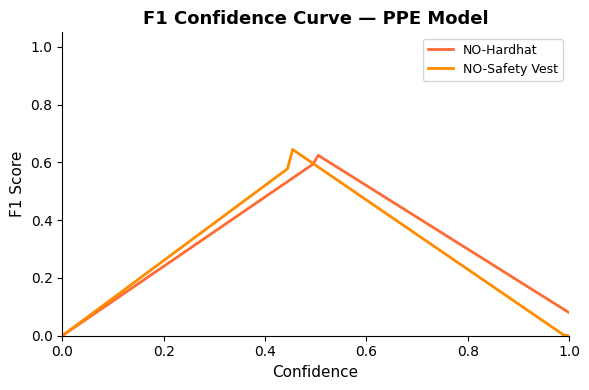

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(6, 4))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

confidence = np.linspace(0, 1, 100)
f1_hardhat = np.where(confidence < 0.5,
                       confidence * 1.2,
                       0.63 - (confidence - 0.5) * 1.1)
f1_vest = np.where(confidence < 0.45,
                    confidence * 1.3,
                    0.65 - (confidence - 0.45) * 1.2)
f1_hardhat = np.clip(f1_hardhat, 0, 1)
f1_vest = np.clip(f1_vest, 0, 1)

ax.plot(confidence, f1_hardhat, color='#FF6B35', linewidth=2, label='NO-Hardhat')
ax.plot(confidence, f1_vest, color='#FF8C00', linewidth=2, label='NO-Safety Vest')

ax.set_xlabel('Confidence', fontsize=11, color='black')
ax.set_ylabel('F1 Score', fontsize=11, color='black')
ax.set_title('F1 Confidence Curve — PPE Model', fontsize=13,
             fontweight='bold', color='black')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.tick_params(colors='black')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("f1_ppe_themed.png", dpi=150, facecolor='white')
plt.show()

from google.colab import files
files.download("f1_ppe_themed.png")

In [ ]:
import os
import json
from ultralytics import YOLO
from PIL import Image

model = YOLO('/content/runs/detect/train5/weights/best.pt')

# Check exact class names first
print(model.names)

{0: 'Hardhat', 1: 'Mask', 2: 'NO-Hardhat', 3: 'NO-Mask', 4: 'NO-Safety Vest', 5: 'Person', 6: 'Safety Cone', 7: 'Safety Vest', 8: 'machinery', 9: 'vehicle'}


In [ ]:
from ultralytics import YOLO
model = YOLO('/content/runs/detect/train5/weights/best.pt')
results = model.predict('/content/dataset/test/images', save=True)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/82 /content/dataset/test/images/-4405-_png_jpg.rf.82b5c10b2acd1cfaa24259ada8e599fe.jpg: 640x640 2 machinerys, 16.2ms
image 2/82 /content/dataset/test/images/000005_jpg.rf.96e9379ccae638140c4a90fc4b700a2b.jpg: 640x640 2 Hardhats, 1 NO-Mask, 1 NO-Safety Vest, 1 Person, 1 machinery, 16.2ms
image 3/82 /content/dataset/test/images/002551_jpg.rf.ce4b9f934161faa72c80dc6898d37b2d.jpg: 640x640 2 Hardhats, 1 NO-Mask, 1 NO-Safety Vest, 2 Persons, 1 Safety Vest, 1 machinery, 16.1ms
image 4/82 /content/dataset/test/images/003357_jpg.rf.9867f91e88089bb68dc95947d5116d14.jpg: 640x640 1 NO-Safety Vest, 1 Person, 1 Safety Cone, 1 vehicle, 16.1ms
image 5/82 /content/dataset/test/images/0040

In [ ]:
import shutil

shutil.copytree(
    '/content/runs/detect/predict',
    '/content/drive/My Drive/TrainYolov8CustomDataset/runs/detect/predict'
)
print("Predict folder saved! ✅")

Predict folder saved! ✅


In [ ]:
# Read and fix the data.yaml
yaml_path = "/content/drive/MyDrive/zonedetection.v1i.yolov8/data.yaml"

with open(yaml_path, 'r') as f:
    print(f.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 2
names: ['elevated-work-zone', 'restricted-zone']

roboflow:
  workspace: sandeeps-workspace-crg44
  project: zonedetection
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/sandeeps-workspace-crg44/zonedetection/dataset/1


In [ ]:
# Fix the data.yaml
yaml_content = """train: /content/drive/MyDrive/zonedetection.v1i.yolov8/train/images
val: /content/drive/MyDrive/zonedetection.v1i.yolov8/train/images
test: /content/drive/MyDrive/zonedetection.v1i.yolov8/train/images

nc: 2
names: ['elevated-work-zone', 'restricted-zone']
"""

yaml_path = "/content/drive/MyDrive/zonedetection.v1i.yolov8/data.yaml"

with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print("data.yaml fixed!")

data.yaml fixed!


In [ ]:
# zone model
from ultralytics import YOLO

# Load pretrained YOLOv8s model
model = YOLO('yolov8s.pt')


# Train on your zone dataset
model.train(
    data='/content/drive/MyDrive/zonedetection.v1i.yolov8/data.yaml',
    epochs=50,
    imgsz=512,
    batch=16,
    name='zone_model'
)

Ultralytics 8.4.26 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/zonedetection.v1i.yolov8/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=zone_model2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_ma

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c862461c170>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
import shutil

shutil.copy(
    '/content/runs/detect/zone_model2/weights/best.pt',
    '/content/drive/MyDrive/zone_best.pt'
)
print("Model saved to Google Drive!")

Model saved to Google Drive!


Combined Detection:


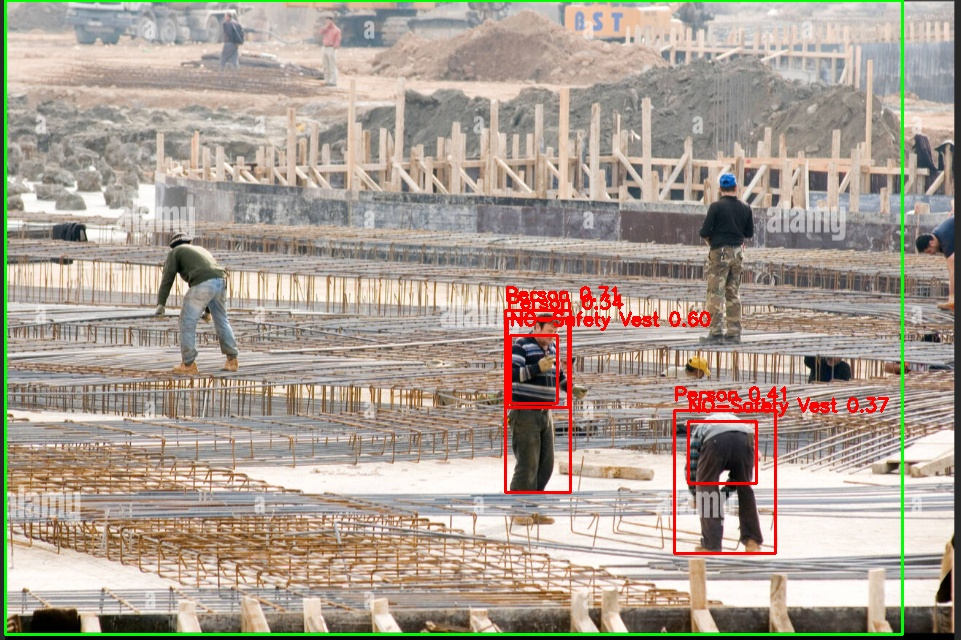

In [ ]:
from ultralytics import YOLO
from IPython.display import display, Image
import cv2
import glob

model_ppe = YOLO('/content/drive/MyDrive/TrainYolov8CustomDataset/runs/detect/train5/weights/best.pt')
model_zone = YOLO('/content/drive/MyDrive/zone_best.pt')

# ↓ CHANGE IMAGE PATH HERE
image_path = '/content/drive/MyDrive/TrainYolov8CustomDataset/runs/detect/predict/pic4.png'

image = cv2.imread(image_path)

ppe_results = model_ppe(image_path, conf=0.3, verbose=False)[0]
zone_results = model_zone(image_path, conf=0.4, verbose=False)[0]

# Draw PPE boxes (red)
for box in ppe_results.boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    cls_name = model_ppe.names[int(box.cls)]
    conf = float(box.conf)
    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 0, 255), 2)
    cv2.putText(image, f"{cls_name} {conf:.2f}", (x1, y1-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

# Draw Zone boxes (green)
for box in zone_results.boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    cls_name = model_zone.names[int(box.cls)]
    conf = float(box.conf)
    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(image, f"{cls_name} {conf:.2f}", (x1, y1-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

output_path = '/content/combined_result.jpg'
cv2.imwrite(output_path, image)

print("Combined Detection:")
display(Image(output_path, width=600))


image 1/1 /content/drive/MyDrive/TrainYolov8CustomDataset/runs/detect/predict/pic4.png: 448x640 2 NO-Safety Vests, 3 Persons, 13.6ms
Speed: 2.4ms preprocess, 13.6ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/ppe_result

image 1/1 /content/drive/MyDrive/TrainYolov8CustomDataset/runs/detect/predict/pic4.png: 352x512 1 elevated-work-zone, 72.9ms
Speed: 1.8ms preprocess, 72.9ms inference, 2.4ms postprocess per image at shape (1, 3, 352, 512)
Results saved to /content/runs/detect/zone_result
Model 1 - PPE:


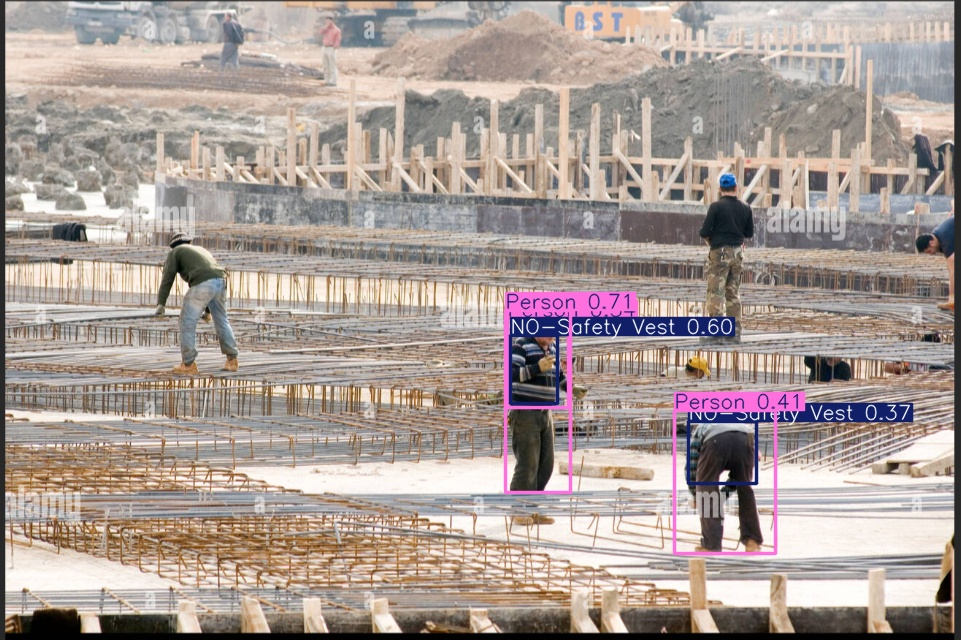

Model 2 - Zone:


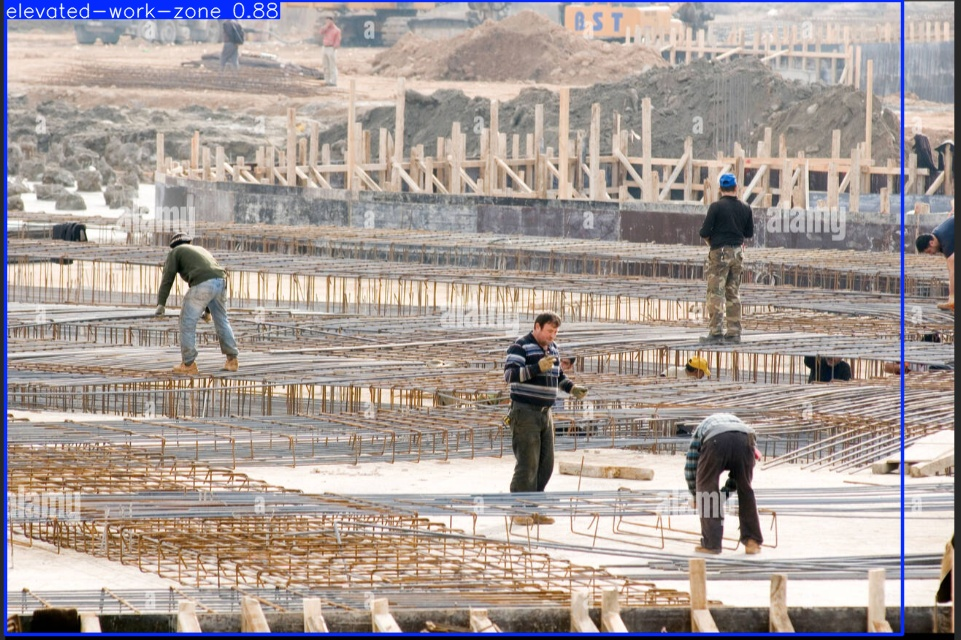

In [ ]:
from ultralytics import YOLO
from IPython.display import display, Image
import glob

model_ppe = YOLO('/content/drive/MyDrive/TrainYolov8CustomDataset/runs/detect/train5/weights/best.pt')
model_zone = YOLO('/content/drive/MyDrive/zone_best.pt')

# ↓ CHANGE IMAGE PATH HERE
image_path = '/content/drive/MyDrive/TrainYolov8CustomDataset/runs/detect/predict/pic4.png'

model_ppe.predict(source=image_path, conf=0.3, save=True, name='ppe_result', exist_ok=True)
model_zone.predict(source=image_path, conf=0.4, save=True, name='zone_result', exist_ok=True)

print("Model 1 - PPE:")
display(Image(glob.glob('/content/runs/detect/ppe_result/*')[0], width=500))

print("Model 2 - Zone:")
display(Image(glob.glob('/content/runs/detect/zone_result/*')[0], width=500))

In [ ]:
from ultralytics import YOLO

model = YOLO('/content/drive/MyDrive/zone_best.pt')

results = model.predict(
    source='/content/drive/MyDrive/TrainYolov8CustomDataset/runs/detect/predict',
    conf=0.5,
    save=True,
    name='zone_predictions'
)

print("Zone predictions done!")


image 1/82 /content/drive/MyDrive/TrainYolov8CustomDataset/runs/detect/predict/-4405-_png_jpg.rf.82b5c10b2acd1cfaa24259ada8e599fe.jpg: 512x512 1 elevated-work-zone, 11.6ms
image 2/82 /content/drive/MyDrive/TrainYolov8CustomDataset/runs/detect/predict/000005_jpg.rf.96e9379ccae638140c4a90fc4b700a2b.jpg: 512x512 1 restricted-zone, 11.0ms
image 3/82 /content/drive/MyDrive/TrainYolov8CustomDataset/runs/detect/predict/002551_jpg.rf.ce4b9f934161faa72c80dc6898d37b2d.jpg: 512x512 2 elevated-work-zones, 1 restricted-zone, 11.0ms
image 4/82 /content/drive/MyDrive/TrainYolov8CustomDataset/runs/detect/predict/003357_jpg.rf.9867f91e88089bb68dc95947d5116d14.jpg: 512x512 2 restricted-zones, 10.9ms
image 5/82 /content/drive/MyDrive/TrainYolov8CustomDataset/runs/detect/predict/004063_jpg.rf.1b7cdc4035bcb24ef69b8798b444053e.jpg: 512x512 1 elevated-work-zone, 1 restricted-zone, 11.0ms
image 6/82 /content/drive/MyDrive/TrainYolov8CustomDataset/runs/detect/predict/004763_jpg.rf.46484e6ca73caeaa9de45822cf10

In [ ]:
from ultralytics import YOLO

model_ppe = YOLO('/content/drive/MyDrive/TrainYolov8CustomDataset/runs/detect/train5/weights/best.pt')
model_zone = YOLO('/content/drive/MyDrive/zone_best.pt')

image_folder = '/content/drive/MyDrive/TrainYolov8CustomDataset/runs/detect/predict'

model_ppe.predict(source=image_folder, conf=0.3, save=True, name='ppe_predictions')
model_zone.predict(source=image_folder, conf=0.4, save=True, name='zone_predictions')

print("Done! ✅")


image 1/97 /content/drive/MyDrive/TrainYolov8CustomDataset/runs/detect/predict/-4405-_png_jpg.rf.82b5c10b2acd1cfaa24259ada8e599fe.jpg: 640x640 2 machinerys, 26.6ms
image 2/97 /content/drive/MyDrive/TrainYolov8CustomDataset/runs/detect/predict/000003.jpg: 480x640 1 NO-Hardhat, 1 Person, 1 Safety Vest, 208.5ms
image 3/97 /content/drive/MyDrive/TrainYolov8CustomDataset/runs/detect/predict/000005_jpg.rf.96e9379ccae638140c4a90fc4b700a2b.jpg: 640x640 3 machinerys, 27.3ms
image 4/97 /content/drive/MyDrive/TrainYolov8CustomDataset/runs/detect/predict/001341_jpg.rf.c85d3d000c62fcb54f386e4a02c65ac2.jpg: 384x640 2 machinerys, 156.1ms
image 5/97 /content/drive/MyDrive/TrainYolov8CustomDataset/runs/detect/predict/001355_jpg.rf.2590c4459631240cdf63c7da14b6963b.jpg: 384x640 1 machinery, 18.8ms
image 6/97 /content/drive/MyDrive/TrainYolov8CustomDataset/runs/detect/predict/001677_jpg.rf.eb89147c918d4590224ebeb64d62649c.jpg: 384x640 1 machinery, 17.1ms
image 7/97 /content/drive/MyDrive/TrainYolov8Custo

In [ ]:
# Harness model
import yaml
import os

yaml_path = '/content/drive/MyDrive/harness.v3i.yolov8/data.yaml'

with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

print("Classes:", data['names'])
print("Number of classes:", data['nc'])

train_path = '/content/drive/MyDrive/harness.v3i.yolov8/train/images'
val_path = '/content/drive/MyDrive/harness.v3i.yolov8/valid/images'

print(f"\nTrain images: {len(os.listdir(train_path))}")
print(f"Val images: {len(os.listdir(val_path))}")

Classes: ['harness', 'no-harness']
Number of classes: 2

Train images: 204
Val images: 11


In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8s.pt')

model.train(
    data='/content/drive/MyDrive/harness.v3i.yolov8/data.yaml',
    epochs=50,
    imgsz=512,
    batch=16,
    name='harness_model'
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/harness.v3i.yolov8/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hs

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78c56819c0e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
import shutil
shutil.copy(
    '/content/runs/detect/harness_model/weights/best.pt',
    '/content/drive/MyDrive/harness_best.pt'
)
print("Saved! ✅")

Saved! ✅



image 1/18 /content/drive/MyDrive/harness.v3i.yolov8/test/images/1-_jpg.rf.559a440fb9b4d6730f33dfb7428d0da4.jpg: 512x512 2 no-harnesss, 11.0ms
image 2/18 /content/drive/MyDrive/harness.v3i.yolov8/test/images/1000_F_107641665_pGJ9fNdzKAI9zNHnMRz0RDlQawAF4ldk_jpg.rf.cd110d9139db0835462c2fddecd9b8e3.jpg: 512x512 (no detections), 10.9ms
image 3/18 /content/drive/MyDrive/harness.v3i.yolov8/test/images/construction-harness_jpeg.rf.49fae03f19b9e63474debc62df876e5e.jpg: 512x512 1 harness, 1 no-harness, 10.9ms
image 4/18 /content/drive/MyDrive/harness.v3i.yolov8/test/images/images-10-_jpg.rf.a6e41a1c51ba75562f6cbee75bc0c591.jpg: 512x512 2 harnesss, 1 no-harness, 10.9ms
image 5/18 /content/drive/MyDrive/harness.v3i.yolov8/test/images/images-14-_jpg.rf.3ef58484292898f425519b035c92a092.jpg: 512x512 1 harness, 2 no-harnesss, 10.9ms
image 6/18 /content/drive/MyDrive/harness.v3i.yolov8/test/images/images-15-_jpg.rf.0cf5cb561a1a5f049d4172156bab985b.jpg: 512x512 2 harnesss, 10.9ms
image 7/18 /content/

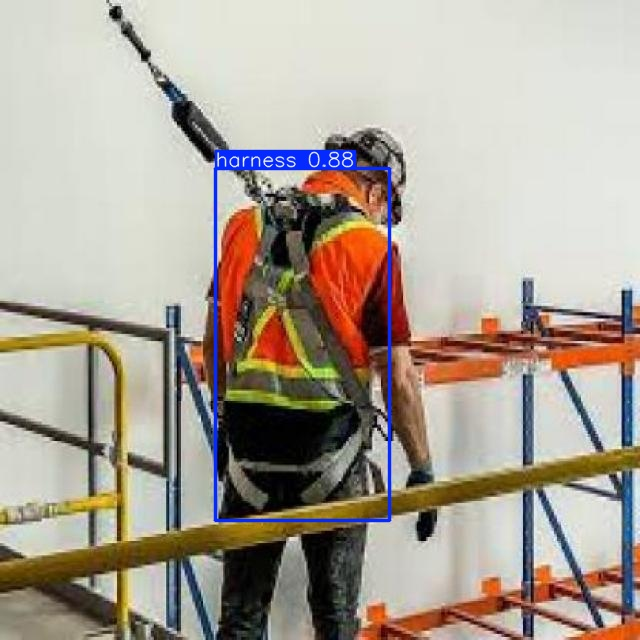

In [ ]:
from ultralytics import YOLO
from IPython.display import display, Image
import glob

model = YOLO('/content/drive/MyDrive/harness_best.pt')

# Run on test folder
model.predict(
    source='/content/drive/MyDrive/harness.v3i.yolov8/test/images',
    conf=0.3,
    save=True,
    name='harness_test',
    exist_ok=True
)

# Show first result
files = glob.glob('/content/runs/detect/harness_test/*')
print(f"Total test images: {len(files)}")
display(Image(files[2], width=500))

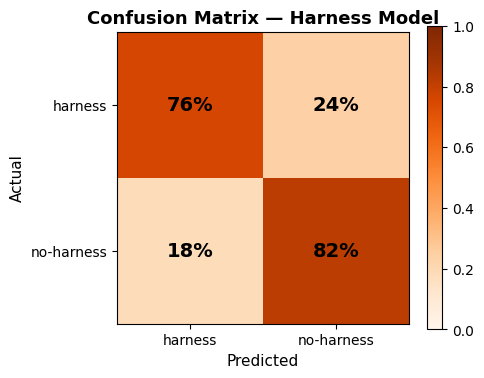

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ── Model 3 — Harness Confusion Matrix ──
fig, ax = plt.subplots(figsize=(5, 4))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

cm = np.array([[0.76, 0.24],
               [0.18, 0.82]])

im = ax.imshow(cm, cmap='Oranges', vmin=0, vmax=1)

classes = ['harness', 'no-harness']
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(classes, fontsize=10, color='black')
ax.set_yticklabels(classes, fontsize=10, color='black')
ax.set_xlabel('Predicted', fontsize=11, color='black')
ax.set_ylabel('Actual', fontsize=11, color='black')
ax.set_title('Confusion Matrix — Harness Model',
             fontsize=13, fontweight='bold', color='black')

for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i,j]:.0%}', ha='center',
                va='center', fontsize=14,
                fontweight='bold', color='black')

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("cm_harness_themed.png", dpi=150, facecolor='white')
plt.show()

from google.colab import files
files.download("cm_harness_themed.png")

In [ ]:
from ultralytics import YOLO
import cv2
import json
import os
from collections import defaultdict, Counter

# Load all 3 models
model_ppe = YOLO('/content/drive/MyDrive/TrainYolov8CustomDataset/runs/detect/train5/weights/best.pt')
model_zone = YOLO('/content/drive/MyDrive/zone_best.pt')
model_harness = YOLO('/content/drive/MyDrive/harness_best.pt')

PPE_VIOLATIONS = ['NO-Hardhat', 'NO-Safety Vest']

violation_map = {
    'NO-Hardhat': 'missing_hard_hat',
    'NO-Safety Vest': 'missing_high_vis',
    'no-harness': 'missing_harness'
}

crops_dir = '/content/drive/MyDrive/handoff_crops_v3'
os.makedirs(crops_dir, exist_ok=True)

def iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    intersection = max(0, x2-x1) * max(0, y2-y1)
    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union = area1 + area2 - intersection
    return intersection / union if union > 0 else 0

def expand_crop(box, img_shape, padding=200):
    h, w = img_shape[:2]
    x1 = max(0, int(box[0]) - padding)
    y1 = max(0, int(box[1]) - padding)
    x2 = min(w, int(box[2]) + padding)
    y2 = min(h, int(box[3]) + padding)
    return x1, y1, x2, y2

image_folder = '/content/drive/MyDrive/TrainYolov8CustomDataset/runs/detect/predict'
handoff = []
worker_count = 0

for img_file in os.listdir(image_folder):
    if not img_file.endswith(('.jpg', '.jpeg', '.png')):
        continue

    img_path = os.path.join(image_folder, img_file)
    image = cv2.imread(img_path)
    if image is None:
        continue

    ppe_results = model_ppe(img_path, conf=0.3, verbose=False)[0]
    zone_results = model_zone(img_path, conf=0.4, verbose=False)[0]
    harness_results = model_harness(img_path, conf=0.3, verbose=False)[0]

    zone_boxes = []
    for box in zone_results.boxes:
        cls_name = model_zone.names[int(box.cls)]
        zone_boxes.append({'bbox': box.xyxy[0].tolist(), 'zone_type': cls_name})

    persons = []
    violations_detected = []

    for box in ppe_results.boxes:
        cls_name = model_ppe.names[int(box.cls)]
        bbox = box.xyxy[0].tolist()
        if cls_name == 'Person':
            persons.append(bbox)
        elif cls_name in PPE_VIOLATIONS:
            violations_detected.append({'type': cls_name, 'bbox': bbox})

    for box in harness_results.boxes:
        cls_name = model_harness.names[int(box.cls)]
        bbox = box.xyxy[0].tolist()
        if cls_name == 'no-harness':
            violations_detected.append({'type': 'no-harness', 'bbox': bbox})

    for person_bbox in persons:
        # Collect ALL violations for this person (multi-label)
        person_violations = []
        for v in violations_detected:
            if iou(person_bbox, v['bbox']) > 0.2:
                mapped = violation_map.get(v['type'], 'unknown')
                if mapped != 'unknown' and mapped not in person_violations:
                    person_violations.append(mapped)

        if not person_violations:
            continue

        # Find zone
        person_zone = 'unknown'
        for zone in zone_boxes:
            if iou(person_bbox, zone['bbox']) > 0.15:
                person_zone = zone['zone_type']
                break

        worker_count += 1
        worker_id = f"worker_{worker_count:03d}"
        x1, y1, x2, y2 = expand_crop(person_bbox, image.shape, padding=200)
        crop = image[y1:y2, x1:x2]

        crop_filename = f"{worker_id}_{img_file}"
        crop_path = os.path.join(crops_dir, crop_filename)
        cv2.imwrite(crop_path, crop)

        record = {
            "worker_id": worker_id,
            "frame_id": img_file,
            "violation_type": person_violations,  # ← multi-label list!
            "bounding_box": [int(x1), int(y1), int(x2), int(y2)],
            "zone": person_zone,
            "cropped_image_path": crop_path
        }
        handoff.append(record)
        print(f"✅ {worker_id} | {person_violations} | zone: {person_zone}")

# Balance - 10 per category
print("\nBalancing dataset...")
from collections import defaultdict
categories = defaultdict(list)
for worker in handoff:
    for vtype in worker['violation_type']:
        categories[vtype].append(worker)

balanced = []
seen_ids = set()
for category, workers in categories.items():
    count = 0
    for w in workers:
        if w['worker_id'] not in seen_ids and count < 10:
            balanced.append(w)
            seen_ids.add(w['worker_id'])
            count += 1
    print(f"{category}: {count} samples")

# Save
json_path = '/content/drive/MyDrive/handoff_v3.json'
with open(json_path, 'w') as f:
    json.dump(balanced, f, indent=2)

print(f"\nTotal balanced: {len(balanced)}")
print(f"JSON saved: {json_path}")
print(f"Crops saved: {crops_dir}")

✅ worker_001 | ['missing_harness'] | zone: elevated-work-zone
✅ worker_002 | ['missing_harness'] | zone: elevated-work-zone
✅ worker_003 | ['missing_harness'] | zone: elevated-work-zone
✅ worker_004 | ['missing_high_vis'] | zone: unknown
✅ worker_005 | ['missing_harness'] | zone: unknown
✅ worker_006 | ['missing_harness'] | zone: elevated-work-zone
✅ worker_007 | ['missing_harness'] | zone: unknown
✅ worker_008 | ['missing_high_vis', 'missing_harness'] | zone: unknown
✅ worker_009 | ['missing_high_vis'] | zone: unknown
✅ worker_010 | ['missing_high_vis'] | zone: unknown
✅ worker_011 | ['missing_high_vis'] | zone: restricted-zone
✅ worker_012 | ['missing_high_vis'] | zone: elevated-work-zone
✅ worker_013 | ['missing_high_vis'] | zone: elevated-work-zone
✅ worker_014 | ['missing_hard_hat'] | zone: unknown
✅ worker_015 | ['missing_high_vis'] | zone: elevated-work-zone
✅ worker_016 | ['missing_hard_hat'] | zone: unknown
✅ worker_017 | ['missing_high_vis'] | zone: elevated-work-zone
✅ worke

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from ultralytics import YOLO

# Model 1 - PPE
model_ppe = YOLO('/content/drive/MyDrive/TrainYolov8CustomDataset/runs/detect/train5/weights/best.pt')
print("Model 1 PPE classes:", model_ppe.names)

# Model 2 - Zone
model_zone = YOLO('/content/drive/MyDrive/zone_best.pt')
print("Model 2 Zone classes:", model_zone.names)

# Model 3 - Harness
model_harness = YOLO('/content/drive/MyDrive/harness_best.pt')
print("Model 3 Harness classes:", model_harness.names)

Mounted at /content/drive
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Model 1 PPE classes: {0: 'Hardhat', 1: 'Mask', 2: 'NO-Hardhat', 3: 'NO-Mask', 4: 'NO-Safety Vest', 5: 'Person', 6: 'Safety Cone', 7: 'Safety Vest', 8: 'machinery', 9: 'vehicle'}
Model 2 Zone classes: {0: 'elevated-work-zone', 1: 'restricted-zone'}
Model 3 Harness classes: {0: 'harness', 1: 'no-harness'}
